In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

from sklearn.linear_model import ElasticNet, ElasticNetCV, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from Bio import SeqIO, Seq
import statsmodels.stats.api as sm

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from inSilicoMut_utils import *
from data_utils import *

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants["gene"] = [val.split("_")[0] for val in who_variants.mutation.values]

solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name=None)["Sheet1"]
solo_results["gene"] = [val.split("_")[0] for val in solo_results.variant.values]

drug_gene_mapping = pd.read_csv("/home/sak0914/who-analysis/data/drug_gene_mapping.csv")

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")

In [3]:
h37Rv_genes.query("Symbol=='rpsA'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
1671,1671,CDS,1833542,1834987,+,0.0,Rv1630,rpsA,Binds mRNA; thus facilitating recognition of t...,30S ribosomal protein S1 RpsA,...,P9WH43,ML1382,MMAR_2433,MSMEG_3833,Mb1656,NaN,NaN,NaN,NaN,NaN


In [20]:
len(h37Rv_seq.seq[1833541:1834987].translate())

482

In [11]:
h37Rv_seq.seq[1833541:1834987]

Seq('ATGCCGAGTCCCACCGTCACCTCGCCGCAAGTAGCCGTCAACGACATAGGCTCT...TGA')

In [21]:
h37Rv_seq.seq[1833541:1834964] + h37Rv_seq.seq[1834965:1834987].translate(), len(h37Rv_seq.seq[1833541:1834964] + h37Rv_seq.seq[1834965:1834987].translate())

(Seq('ATGCCGAGTCCCACCGTCACCTCGCCGCAAGTAGCCGTCAACGACATAGGCTCT...QRL'), 1430)

In [22]:
482*3

1446

In [ ]:
awk 'FNR==NR {a[$1]; next}; $1 in a' indexes.csv datatable.csv

In [79]:
coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

lineages = coll_2014.copy()
lineages["Count"] = 1
lineages = lineages.pivot(index="lineage", columns="position", values="Count").fillna(0).astype(int)

num_lineages = lineages.shape[1]
assert np.min(lineages.sum(axis=1).values) == 1
assert np.max(lineages.sum(axis=1).values) == 1
print(lineages.shape)

(62, 62)


In [85]:
np.zeros(len(lineages.values)).reshape(1, -1).shape

(1, 62)

In [69]:
drug_abbr = "INH"
drug = "Isoniazid"
# cc = cc_df.query("antb==@drug.upper()")["mgit960"].values[0]
cc = cc_df.query("antb==@drug.upper()")["m7h10"].values[0]
print(cc)

df_train = pd.read_csv(os.path.join(data_path, drug_abbr, "data_for_model.csv"))
df_train.shape

0.2


(9703, 19)

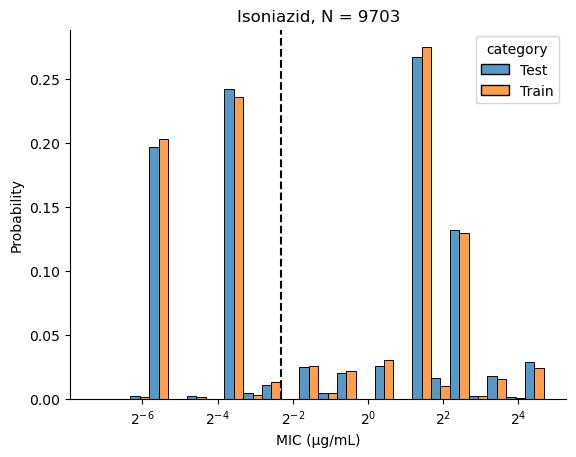

In [70]:
fig, ax = plt.subplots()

df_train["category"] = df_train["category"].replace("original_train_set", "Train").replace("original_test_set", "Test")

sns.histplot(data=df_train,
             x=f"{drug_abbr}_midpoint",
             stat="probability",
             hue="category",
             log_scale=2,
             multiple="dodge",
             common_norm=False,
             ax=ax
            )

plt.axvline(x=cc, color="black", linestyle='--', linewidth=1.5)
plt.title(f"{drug}, N = {len(df_train)}")
plt.xlabel("MIC (µg/mL)")
sns.despine()
plt.savefig(f"/home/sak0914/MtbQuantCNN/analysis/TRUST/{drug_abbr}_train_test.png", dpi=300)

In [89]:
PZA_ridge_input = np.load("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_lineage/ridge/combined_X.npy")
PZA_ridge_input.shape

(1204, 4515)

In [92]:
X_Reg = np.zeros((len(lineages.values), PZA_ridge_input.shape[1]))
X_Reg.shape

(62, 4515)

In [96]:
df_pza = pd.read_csv(os.path.join(data_path, "PZA/data_for_model.csv"))
df_pza.shape

(1204, 18)

In [98]:
data_path

'/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs'

In [110]:
pncA = Alignment.from_file(open("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/TRUST/fastas/pncA.fasta"), alphabet='-ACGT')
pncA.L, pncA.N

(4812, 1398)

In [107]:
pncA_seq = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/TRUST/fastas/pncA.fasta", "fasta")]
len(pncA_seq)

1398

In [109]:
pncA_seq[-1]

('MT_H37Rv',
 Seq('CCCGACAGGCTAGCCGCCCCGCCCCCATTCCTGCACTGCGCATGCCGCGTGGCC...TGA'))

In [102]:
pncA

In [2]:
who_variants.drug.unique()

array(['STM', 'PZA', 'KAN', 'RIF', 'EMB', 'CAP', 'INH', 'ETH', 'LZD',
       'MXF', 'LEV', 'AMI', 'DLM', 'CFZ', 'BDQ'], dtype=object)

In [3]:
who_variants.confidence.unique()

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '3) Uncertain significance', '4) Not assoc w R - Interim',
       '5) Not assoc w R'], dtype=object)

In [4]:
drug = "KAN"
who_variants.query("drug==@drug & confidence=='1) Assoc w R'")

,drug,genome_index,confidence,mutation,gene
40,KAN,2715344,1) Assoc w R,eis_c.-12C>T,eis
159,KAN,2715339,1) Assoc w R,eis_c.-8delC,eis
161,KAN,2715342,1) Assoc w R,eis_c.-10G>A,eis
162,KAN,2715369,1) Assoc w R,eis_c.-37G>T,eis
164,KAN,1473329,1) Assoc w R,rrs_n.1484G>T,rrs
185,KAN,2715346,1) Assoc w R,eis_c.-14C>T,eis
188,KAN,1473246,1) Assoc w R,rrs_n.1401A>G,rrs


In [5]:
drug = "AMI"
who_variants.query("drug==@drug & confidence=='1) Assoc w R'")

,drug,genome_index,confidence,mutation,gene
187,AMI,2715346,1) Assoc w R,eis_c.-14C>T,eis
190,AMI,1473246,1) Assoc w R,rrs_n.1401A>G,rrs


In [6]:
drug = "CAP"
who_variants.query("drug==@drug & confidence=='1) Assoc w R'")

,drug,genome_index,confidence,mutation,gene
64,CAP,1918647,1) Assoc w R,tlyA_p.Asn236Lys,tlyA
65,CAP,1918160,1) Assoc w R,tlyA_p.Leu74Pro,tlyA
163,CAP,1473247,1) Assoc w R,rrs_n.1402C>T,rrs
166,CAP,1473329,1) Assoc w R,rrs_n.1484G>T,rrs
189,CAP,1473246,1) Assoc w R,rrs_n.1401A>G,rrs


In [8]:
h37Rv_genes.query("Symbol=='eis'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
2484,2484,CDS,2714124,2715332,-,0.0,Rv2416c,eis,"Acetylation, substrate unknown. Involved in in...","Enhanced intracellular survival protein Eis, G...",...,P9WFK7,NaN,MMAR_3740,MSMEG_3513,Mb2439c,NaN,NaN,NaN,NaN,NaN


In [42]:
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/isolate_variants.tsv", usecols=["Isolate"], sep="\t")

all_isolates = isolate_variants.Isolate.unique()
len(all_isolates)

12595

In [43]:
fNames = os.listdir("/n/scratch3/users/s/sak0914/annotated_VCF")
all_isolates = set(isolate_variants_1.Isolate).union(isolate_variants_2.Isolate)
len(all_isolates)

12599

In [44]:
missing_isolates = []

for fName in fNames:
    if fName.split(".")[0] not in all_isolates:
        missing_isolates.append(fName.split(".")[0])

print(len(missing_isolates))

if len(missing_isolates) > 0:
    pd.Series(missing_isolates).to_csv("/home/sak0914/missing_fNames.txt", index=False, header=None)

0

# Read in Elastic Net Model Fit on `original_train_set` only

In [112]:
drug = "PZA"
scaler = StandardScaler()

regression_matrix = pd.read_pickle(os.path.join(data_path, drug, "whole_genome/regression_matrix_no_drug_res.pkl"))
pca_df = pd.read_csv(os.path.join(data_path, drug, "whole_genome/PCA_eigenvec_df.csv"), index_col=0)

df_phenos = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"), index_col=0)

# elastic_net_model = pickle.load(open(os.path.join(data_path, drug, "whole_genome/model_no_drug_res.sav"), 'rb'))
elastic_net_model = pickle.load(open(os.path.join(data_path, drug, "whole_genome/full_feature_select.sav"), 'rb'))
print(f"alpha = {elastic_net_model.alpha_}, L1 = {elastic_net_model.l1_ratio_}")
coef_df = pd.DataFrame({"feature": list(regression_matrix.columns) + [f"PC{num}" for num in range(12)], "coef": np.squeeze(elastic_net_model.coef_)})

alpha = 0.1, L1 = 0.4


In [113]:
df_phenos["Lineage"].value_counts()

Lineage
4          1078
2           112
3            10
1             2
BOVAFRI       2
Name: count, dtype: int64

In [114]:
df_phenos.groupby("Lineage")[["Binary", f"{drug}_midpoint"]].mean()

,Binary,PZA_midpoint
Lineage,,
1,0.000000,27.500000
2,0.491071,167.633929
3,0.000000,22.500000
4,0.491651,198.140074
BOVAFRI,1.000000,300.000000


# Extract features with `coef != 0` (relevant by the L1 part of the model)

In [115]:
# get only significant features by permutation test, them perform bootstrapping to get confidence intervals
# sig_features = coef_df.query("Bonferroni_pval < 0.05").feature.values

# get only features where coef != 0. These are shrunk to 0 by the LASSO part of the Elastic Net model
sig_features = coef_df.query("coef != 0").feature.values

if len(coef_df.query("coef != 0 & feature.str.contains('PC')")) == 0:
    include_PC = False
else:
    include_PC = True

print(f"{len(sig_features)} significant features, include principal components = {include_PC}")
# features significant by permutation test are a subset of those with nonzero coefficients
# assert len(set(coef_df.query("Bonferroni_pval < 0.05").feature.values) - set(sig_features)) == 0

regression_matrix_downselect = regression_matrix[sig_features]
assert regression_matrix_downselect.shape[1] == len(sig_features)

4141 significant features, include principal components = False


# Build a Ridge regression model using downselected features

In [117]:
# ridge_model = RidgeCV(alphas=np.logspace(-5, 5, 11))

# if include_PC:
#     X_train = scaler.fit_transform(pd.concat([regression_matrix_downselect.loc[df_phenos.query("category=='original_train_set'").index.values],
#                                               pca_df.loc[df_phenos.query("category=='original_train_set'").index.values]
#                                              ], axis=1).values
#                                   )
    
#     X_test = scaler.fit_transform(pd.concat([regression_matrix_downselect.loc[df_phenos.query("category=='original_test_set'").index.values],
#                                              pca_df.loc[df_phenos.query("category=='original_test_set'").index.values]
#                                             ], axis=1).values
#                                   )
#     X = scaler.fit_transform(pd.concat([regression_matrix_downselect.loc[df_phenos.index.values],
#                                         pca_df.loc[df_phenos.index.values]
#                                         ], axis=1).values
#                                   )
# else:
#     X_train = scaler.fit_transform(regression_matrix_downselect.loc[df_phenos.query("category=='original_train_set'").index.values].values)
    
#     X_test = scaler.fit_transform(regression_matrix_downselect.loc[df_phenos.query("category=='original_test_set'").index.values].values)

#     X = scaler.fit_transform(regression_matrix_downselect.loc[df_phenos.index.values].values)

# y_train = np.log2(df_phenos.query("category=='original_train_set'")[f"{drug}_midpoint"].values)
# y_test = np.log2(df_phenos.query("category=='original_test_set'")[f"{drug}_midpoint"].values)
# y = np.log2(df_phenos[f"{drug}_midpoint"].values)

# Get predictions on the test dataset and see how well the model does

In [32]:
ridge_model.fit(X_train, y_train)
print(ridge_model.alpha_)

# use the model trained on the training data to get predictions on the training data only
y_pred = ridge_model.predict(X_test)
pred_df = df_phenos[["category", f"{drug}_lower_bound", f"{drug}_upper_bound"]].loc[regression_matrix_downselect.index.values].query("category=='original_test_set'").reset_index()
pred_df["y_test"] = y_test
pred_df["y_pred"] = y_pred
pred_df["y_test_exp"] = np.exp2(pred_df["y_test"])
pred_df["y_pred_exp"] = np.exp2(pred_df["y_pred"])

within_doubling = len(pred_df.query(f"{drug}_lower_bound / 2 <= y_pred_exp <= {drug}_upper_bound * 2")) / len(pred_df)

print(f"MAE: {np.mean(np.abs(y_pred - y_test))}, MSE: {np.mean(np.exp2(y_pred - y_test))}, EA: {within_doubling}")

MAE: 1.1167378873072742, MSE: 1.5286916819182876, EA: 0.6680672268907563


In [33]:
ridge_model.fit(X, y)
print(ridge_model.alpha_)

# use the model trained on the full data to get predictions on the training data only
y_pred = ridge_model.predict(X_test)
pred_df = df_phenos[["category", f"{drug}_lower_bound", f"{drug}_upper_bound"]].loc[regression_matrix_downselect.index.values].query("category=='original_test_set'").reset_index()
pred_df["y_test"] = y_test
pred_df["y_pred"] = y_pred
pred_df["y_test_exp"] = np.exp2(pred_df["y_test"])
pred_df["y_pred_exp"] = np.exp2(pred_df["y_pred"])

within_doubling = len(pred_df.query(f"{drug}_lower_bound / 2 <= y_pred_exp <= {drug}_upper_bound * 2")) / len(pred_df)

print(f"MAE: {np.mean(np.abs(y_pred - y_test))}, MSE: {np.mean(np.exp2(y_pred - y_test))}, EA: {within_doubling}")

100.0
MAE: 0.7241207899566382, MSE: 1.145057457910479, EA: 0.8445378151260504


In [5]:
#pred_df.query(f"~({drug}_lower_bound / 2 <= y_pred_exp <= {drug}_upper_bound * 2) & ({drug}_upper_bound != 500000)")

# Permutation Test to Find Significant Features

In [22]:
# use the regularization parameter determined above
def perform_permutation_test(model, X, y, num_reps, progress_bar=False):

    reg_param = model.alpha_
            
    coefs = []    
    for i in range(num_reps):

        if i == 0:
            print(f"Fitting {num_reps} permuted Ridge models using regularization parameter = {reg_param}")
            
        # shuffle phenotypes. np.random.shuffle works in-place
        y_permute = y.copy()
        np.random.shuffle(y_permute)

        rep_model = Ridge(alpha=reg_param, max_iter=100000)
        rep_model.fit(X, y_permute)
        coefs.append(np.squeeze(rep_model.coef_))
        
        if progress_bar:
            if i % int(num_reps / 10) == 0:
                print(i)
        
    return pd.DataFrame(coefs)
    
    
def add_pvalues(drug, matrix, model, permutation_df, feat_array):

    coef_df = pd.DataFrame({"feature": feat_array, "coef": np.squeeze(model.coef_)})
    coef_df["indel"] = [0 if "_" in val and "NC" not in val else 1 for val in coef_df.feature.values]
    # coef_df["WHO_cat1"] = coef_df["feature"].map(dict(zip(who_variants.query("drug!=@drug")["mutation"], who_variants.query("drug!=@drug")["confidence"])))
    coef_df["WHO_cat1"] = coef_df["feature"].map(dict(zip(who_variants["mutation"], who_variants["confidence"])))
    coef_df["gene"] = ["_".join(val.split("_")[:-1]) if "_" in val else val for val in coef_df.feature.values]

    for i, row in coef_df.iterrows():
        # p-value is the proportion of permutation coefficients that are AT LEAST AS EXTREME as the test statistic
        # ONE-SIDED because we are interested in the sign of the coefficient
        if row["coef"] > 0:
            coef_df.loc[i, "pval"] = np.mean(permutation_df[row["feature"]] >= row["coef"])
        else:
            coef_df.loc[i, "pval"] = np.mean(permutation_df[row["feature"]] <= row["coef"])
            
    _, bh_pvals, _, _ = sm.multipletests(coef_df["pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
    _, bonferroni_pvals, _, _ = sm.multipletests(coef_df["pval"], method='bonferroni', is_sorted=False, returnsorted=False)

    coef_df["BH_pval"] = bh_pvals
    coef_df["Bonferroni_pval"] = bonferroni_pvals
    
    return coef_df

In [118]:
# ridge_permutation_df = perform_permutation_test(ridge_model, X, y, 1000, progress_bar=True)

if include_PC:
    feat_array = np.concatenate([sig_features, pca_df.columns])
else:
    feat_array = np.copy(sig_features)

# ridge_permutation_df.columns = feat_array
# ridge_permutation_df.to_csv(os.path.join(data_path, drug, "whole_genome/permutation_df_ridge.csv"), index=False)
ridge_permutation_df = pd.read_csv(os.path.join(data_path, drug, "whole_genome/permutation_df_ridge.csv"))

In [119]:
# ridge_coef_df = add_pvalues(drug, regression_matrix_downselect, ridge_model, ridge_permutation_df, feat_array)
# ridge_coef_df.to_csv(os.path.join(data_path, drug, "whole_genome/ridge_results.csv"), index=False)
ridge_coef_df = pd.read_csv(os.path.join(data_path, drug, "whole_genome/ridge_results.csv"))

In [120]:
ridge_coef_df.query("pval < 0.05 & indel==1 & ~gene.str.contains('|'.join(['PPE', 'PGRS'])) & (coef > 0.1 | coef < -0.1)").sort_values("coef", ascending=False)

,feature,coef,indel,WHO_cat1,gene,pval,BH_pval,Bonferroni_pval
4120,pncA,0.527182,1,NaN,pncA,0.000,0.000000,0.0
3993,Rv2041c,0.137648,1,NaN,Rv2041c,0.023,0.378973,1.0
3927,Rv0196,-0.100226,1,NaN,Rv0196,0.046,0.378973,1.0
3881,NC_2854,-0.128827,1,NaN,NC,0.049,0.378973,1.0


In [48]:
h37Rv_coords.query("region=='NC_2854'")

,pos,region
4156729,4156730,NC_2854
4156730,4156731,NC_2854
4156731,4156732,NC_2854
4156732,4156733,NC_2854
4156733,4156734,NC_2854
...,...,...
4156975,4156976,NC_2854
4156976,4156977,NC_2854
4156977,4156978,NC_2854
4156978,4156979,NC_2854


In [ ]:
Rv3712 (upstream, ligase), Rv2041c (sugar transport), Rv0196 (transcriptional regulatory protein), bacA

In [37]:
solo_results.query("drug=='Pyrazinamide' & Initial_Confidence_Grading in ['1) Assoc w R', '2) Assoc w R - Interim']").gene.unique()

array(['pncA'], dtype=object)

In [40]:
#solo_results.query("drug=='Pyrazinamide' & Initial_Confidence_Grading in ['1) Assoc w R', '2) Assoc w R - Interim']")

In [122]:
ridge_coef_df.query("pval < 0.05 & indel==0 & ~gene.str.contains('|'.join(['PPE', 'PGRS']))  & (coef > 0.05 | coef < -0.05)").sort_values("coef", ascending=False)#.head(20)

,feature,coef,indel,WHO_cat1,gene,pval,BH_pval,Bonferroni_pval
2264,bacA_p.Trp627Arg,0.200912,0,NaN,bacA,0.000,0.000000,0.0
3463,pncA_p.Gln10Arg,0.197677,0,1) Assoc w R,pncA,0.020,0.378973,1.0
3443,pncA_c.309C>G,0.154411,0,NaN,pncA,0.006,0.211584,1.0
3459,pncA_p.Asp49Asn,0.135162,0,2) Assoc w R - Interim,pncA,0.034,0.378973,1.0
3501,pncA_p.Thr76Pro,0.123550,0,1) Assoc w R,pncA,0.036,0.378973,1.0
3465,pncA_p.Gln141Pro,0.101579,0,1) Assoc w R,pncA,0.035,0.378973,1.0
903,Rv0893c_p.Asp33Glu,0.057140,0,NaN,Rv0893c,0.044,0.378973,1.0
3200,nirB_p.Thr833Pro,0.057140,0,NaN,nirB,0.044,0.378973,1.0


In [52]:
significant_SNP_df = pd.DataFrame(ridge_coef_df.query("pval < 0.05 & indel==0 & ~gene.str.contains('|'.join(['PPE', 'PGRS']))").groupby("gene")["coef"].count())
significant_SNP_df.query("coef > 1").sort_values("coef", ascending=False)

,coef
gene,
pncA,11
Rv3467,5
Rv1199c,3
Rv0485,2
Rv0797,2
Rv1313c,2
Rv2752c,2
Rv3524,2
Rv3813c,2


In [50]:
ridge_coef_df.query("pval < 0.05 & indel==0 & gene in ['Rv3467', 'Rv1199c']")

,feature,coef,indel,WHO_cat1,gene,pval,BH_pval,Bonferroni_pval
1039,Rv1199c_p.Ala168Thr,0.010598,0,NaN,Rv1199c,0.012,0.314506,1.0
1050,Rv1199c_p.Ile139Ser,0.013026,0,NaN,Rv1199c,0.000,0.000000,0.0
1051,Rv1199c_p.Ile281Thr,0.003930,0,NaN,Rv1199c,0.004,0.186112,1.0
1979,Rv3467_p.Ala214Val,0.027496,0,NaN,Rv3467,0.028,0.378973,1.0
1980,Rv3467_p.Asn222Thr,0.017846,0,NaN,Rv3467,0.016,0.378973,1.0
1981,Rv3467_p.Asp232His,0.017846,0,NaN,Rv3467,0.016,0.378973,1.0
1982,Rv3467_p.Cys226Phe,0.017846,0,NaN,Rv3467,0.016,0.378973,1.0
1987,Rv3467_p.Tyr236His,0.017846,0,NaN,Rv3467,0.016,0.378973,1.0


In [77]:
# length ~1.05 million
cetr = pd.read_csv("/home/sak0914/CETR_isolate_details.csv")
cetr.shape

(1048575, 44)

In [88]:
pza_df = cetr.loc[~pd.isnull(cetr["PZA"])].reset_index(drop=True)
pza_df.shape

(1266, 44)

In [134]:
count_missing = 0
missing_sample_idx = []

for i, row in pza_df.iterrows():

    sample_ids_lst = [row["ID"], row["WGSAccessionNumber/Run Accession"], row["BioSample"], row["Alt ID"]]
    found = False
    
    for sample_id in sample_ids_lst:

        if not pd.isnull(sample_id):
            
            fNames = [f"/n/scratch3/users/s/sak0914/annotated_VCF/{sample_id.replace('-', '')}.eff.vcf", 
                      f"/n/scratch3/users/s/sak0914/annotated_VCF/{sample_id.replace('-', '_')}.eff.vcf",
                      f"/n/scratch3/users/s/sak0914/annotated_VCF/{sample_id.replace('.00', '')}.eff.vcf",
                      f"/n/scratch3/users/s/sak0914/annotated_VCF/{sample_id.replace('.0', '')}.eff.vcf"
                     ]
    
            for fName in fNames:
                if os.path.isfile(fName):
                    found = True
                    break
                else:
                    pass
                
    if not found:
        count_missing += 1
        missing_sample_idx.append(i)

# the original PZA sample count was 1250, so I think the 16 missing samples failed QC or something, so we don't have the .vcf.gz files for them
print(f"{count_missing} missing samples")

16 missing samples


In [56]:
vcf_eff = glob.glob("/n/scratch3/users/s/sak0914/annotated_VCF/*.eff.vcf")
vcfs = glob.glob("/n/scratch3/users/s/sak0914/annotated_VCF/*.vcf")
set(vcfs) - set(vcf_eff)

set()

In [44]:
h37Rv_genes.query("Symbol=='pca'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
3048,3048,CDS,3319663,3323046,-,0.0,Rv2967c,pca,Involved in gluconeogenesis and lipogenesis. P...,Probable pyruvate carboxylase Pca (pyruvic car...,...,I6YEU0,"ML1665,ML1665c",MMAR_1749,MSMEG_2412,Mb2991c,NaN,NaN,NaN,NaN,NaN


# Analysis of Mutations

In [15]:
output_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA"

df_PZA = pd.read_csv(os.path.join(output_path, "data_for_model.csv"))
PZA_isolate_variants = pd.read_csv(os.path.join(output_path, "isolate_variants_FULL_fixed.tsv"), sep="\t")
matrix = pd.read_pickle(os.path.join(output_path, "whole_genome/regression_matrix_no_drug_res.pkl"))

matrix["NC_2854"].value_counts()

NC_2854
0.0    1182
1.0       8
Name: count, dtype: int64

In [8]:
df_PZA.groupby("Lineage")["PZA_midpoint"].mean()

Lineage
1     51.666667
2    167.633929
3     29.545455
4    198.140074
Name: PZA_midpoint, dtype: float64

In [3]:
search_lst = matrix.loc[matrix["NC_2854"]==1].index.values
search_lst

array(['02R1685', '1753', 'NLA000100510', 'NLA009801164', 'Peru4049',
       'Peru4079', 'Peru4090', 'Peru5072'], dtype=object)

In [16]:
df_PZA.shape

(1204, 18)

In [17]:
df_PZA.query("ROLLINGDB_ID in @search_lst")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,PZA,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,Path,Coll2014,Binary,Lineage,category
42,02R1685,ERS2401236,02-R1685,Peru,farhat_internal,NaN,NaN,MSLI,m7h10,>100,100.0,500000.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.3.3,1,4,original_train_set
109,1753,ERS2401104,1753,Netherlands,farhat_internal,NaN,NaN,RIVM,m7h10,<=10,0.0,10.0,5.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.2.1,0,4,original_train_set
223,NLA000100510,ERS2401413,NLA000100510,Netherlands,farhat_internal,NaN,NaN,RIVM,m7h10,<=10,0.0,10.0,5.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.4.1.1,0,4,original_train_set
249,NLA009801164,ERS2401338,NLA009801164,Netherlands,farhat_internal,NaN,NaN,RIVM,m7h10,>100,100.0,500000.0,100.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.2.1,1,4,original_train_set
617,Peru4049,SAMN05919570,Peru4049,Peru,farhat_internal,NaN,NaN,NJH,m7h10,<=25,0.0,25.0,12.5,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.3.4,0,4,original_train_set
644,Peru4079,SAMN05919600,Peru4079,Peru,farhat_internal,NaN,NaN,NJH,m7h10,<=25,0.0,25.0,12.5,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.1,0,4,original_train_set
655,Peru4090,SAMN05919610,Peru4090,Peru,farhat_internal,NaN,NaN,NJH,m7h10,<=25,0.0,25.0,12.5,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.3.3,0,4,original_train_set
1090,Peru5072,SAMN05916384,Peru5072,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>500,500.0,500000.0,500.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,4.1.1,1,4,original_test_set


In [25]:
PZA_isolate_variants.query("Isolate in ['02R1685', 'NLA009801164', 'Peru5072'] & POS >= 2288681 & POS <= 2289241")

,POS,REF,ALT,FILTER,QUAL,AF,GENE,EFFECT,NUC,PROT,Isolate,QC,REF_len,ALT_len,mutation
283565,2289090,T,C,PASS,1482.0,1.0,pncA,missense_variant,c.152A>G,p.His51Arg,02R1685,1.00,1,1,pncA_p.His51Arg
567639,2288955,T,G,Amb,1274.0,0.41,pncA,missense_variant,c.287A>C,p.Lys96Thr,NLA009801164,0.41,1,1,pncA_p.Lys96Thr


In [33]:
PZA_isolate_variants.query("Isolate=='Peru5072' & FILTER=='PASS'")# & GENE.str.contains('pncA')")#.GENE.unique()

,POS,REF,ALT,FILTER,QUAL,AF,GENE,EFFECT,NUC,PROT,Isolate,QC,REF_len,ALT_len,mutation
210543,24698,GCCGCGTTGCTCGGGGTAA,G,PASS,0.0,0.6,fhaA,disruptive_inframe_deletion,c.729_746delTTACCCCGAGCAACGCGG,p.Tyr244_Gly249del,Peru5072,1.0,19,1,fhaA_p.Tyr244_Gly249del
210544,24720,CGTTGCTCGGGGTAACCGC,C,PASS,0.0,.,fhaA,conservative_inframe_deletion,c.707_724delGCGGTTACCCCGAGCAAC,p.Gly237_Arg242del,Peru5072,1.0,19,1,fhaA_p.Gly237_Arg242del
210545,29482,CA,C,PASS,0.0,1.0,Rv0025,frameshift_variant,c.241delA,p.Thr81fs,Peru5072,1.0,2,1,Rv0025_p.Thr81fs
210546,32349,CCCGCGCGTCGGCGATGCGTCGCGTCGAGTCGGCGATG,C,PASS,0.0,0.75,Rv0029,frameshift_variant,c.295_331delCGCGCGTCGGCGATGCGTCGCGTCGAGTCGGCGATGC,p.Arg99fs,Peru5072,1.0,38,1,Rv0029_p.Arg99fs
210547,55553,C,CCGCCGT,PASS,1893.0,0.83,ponA1,conservative_inframe_insertion,c.1893_1894insCCGTCG,p.Pro631_Glu632insProSer,Peru5072,1.0,1,7,ponA1_p.Pro631_Glu632insProSer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635246,4386709,C,T,PASS,2437.0,1.0,Rv3901c,missense_variant,c.106G>A,p.Ala36Thr,Peru5072,1.0,1,1,Rv3901c_p.Ala36Thr
1635247,4391565,G,C,PASS,2089.0,1.0,Rv3906c,missense_variant,c.42C>G,p.Ile14Met,Peru5072,1.0,1,1,Rv3906c_p.Ile14Met
1635248,4393178,A,G,PASS,1787.0,1.0,pcnA-mutT4,intergenic_region,n.4393178A>G,.,Peru5072,1.0,1,1,pcnA-mutT4_n.4393178A>G
1635249,4400246,G,A,PASS,1870.0,1.0,sigM,missense_variant,c.61G>A,p.Asp21Asn,Peru5072,1.0,1,1,sigM_p.Asp21Asn


In [23]:
who_variants.query("drug=='PZA' & mutation in ['pncA_p.His51Arg', 'pncA_p.Lys96Thr']")

,drug,genome_index,confidence,mutation,gene
5,PZA,2289090,1) Assoc w R,pncA_p.His51Arg,pncA
21,PZA,2288955,1) Assoc w R,pncA_p.Lys96Thr,pncA


In [24]:
who_variants.query("drug=='PZA' & confidence=='1) Assoc w R'").gene.unique()

array(['pncA'], dtype=object)

In [4]:
PZA_isolate_variants.query("Isolate in @search_lst and (POS > 4156729 & POS < 4156981) & FILTER == 'PASS'")

,POS,REF,ALT,FILTER,QUAL,AF,GENE,EFFECT,NUC,PROT,Isolate,QC,REF_len,ALT_len,mutation
6907,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,02R1685,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del
19109,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,1753,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del
42165,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,NLA000100510,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del
48134,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,NLA009801164,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del
116982,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,Peru4049,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del
122444,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,Peru4079,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del
124509,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,Peru4090,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del
210716,4156849,CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGA...,C,PASS,0.0,.,dnaQ-Rv3712,intergenic_region,n.4156850_4156967del,.,Peru5072,1.0,119,1,dnaQ-Rv3712_n.4156850_4156967del


In [41]:
len(h37Rv_seq[4156848:4156965])

117

In [46]:
str(h37Rv_seq[4156849:4156967].seq)

'TGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGAGCTTGCGATCGCCCTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGAGCTTGCGATCGCCC'

In [47]:
4156850-4156967

-117

In [48]:
4156850-4156967

-117

In [34]:
PZA_isolate_variants.query("Isolate in @search_lst and (POS > 4156729 & POS < 4156981) & FILTER == 'PASS'")["REF"].unique()

array(['CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGAGCTTGCGATCGCCCTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGAGCTTGCGATCGCCC'],
      dtype=object)

In [35]:
len('CTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGAGCTTGCGATCGCCCTGAATCCAACGCGGGCGACCCGCCGCACCCGGCGACAAGCGCCGAGCTTGCGATCGCCC')

119

In [ ]:
bcftools filter -i "POS==4156849" 02R1685.eff.vcf